# Capítulo 19 — Dispersão de Poluentes: laboratório numérico

**Curso de Meteorologia Prática** — baseado em R. Stull, *Practical Meteorology* (CC BY-NC-SA 4.0).

| Caso | O que fazemos | Ferramenta |
|---|---|---|
| 1 | pluma gaussiana: o campo de concentração | NumPy |
| 2 | estabilidade esculpe a pluma (looping/coning/fanning) | NumPy |
| 3 | o modelo de caixa da cidade: episódios de poluição | `solve_ivp` |
| 4 | passeio aleatório: a difusão nasce do caos | NumPy |

Exercícios numéricos N1–N4 no fim; soluções em `cap19_solucoes.ipynb`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import sys; sys.path.append('../comum')
from estilo_meteo import aplicar_estilo, CORES
aplicar_estilo()

## Caso 1 — A pluma gaussiana

Fonte contínua de taxa $Q$ numa chaminé de altura $H$, vento $U$; a turbulência espalha em gaussianas crescentes, com **fonte-imagem** no chão (T2):
$$C(x,y,z) = \frac{Q}{2\pi U \sigma_y\sigma_z}\,e^{-y^2/2\sigma_y^2}\left[e^{-(z-H)^2/2\sigma_z^2} + e^{-(z+H)^2/2\sigma_z^2}\right].$$

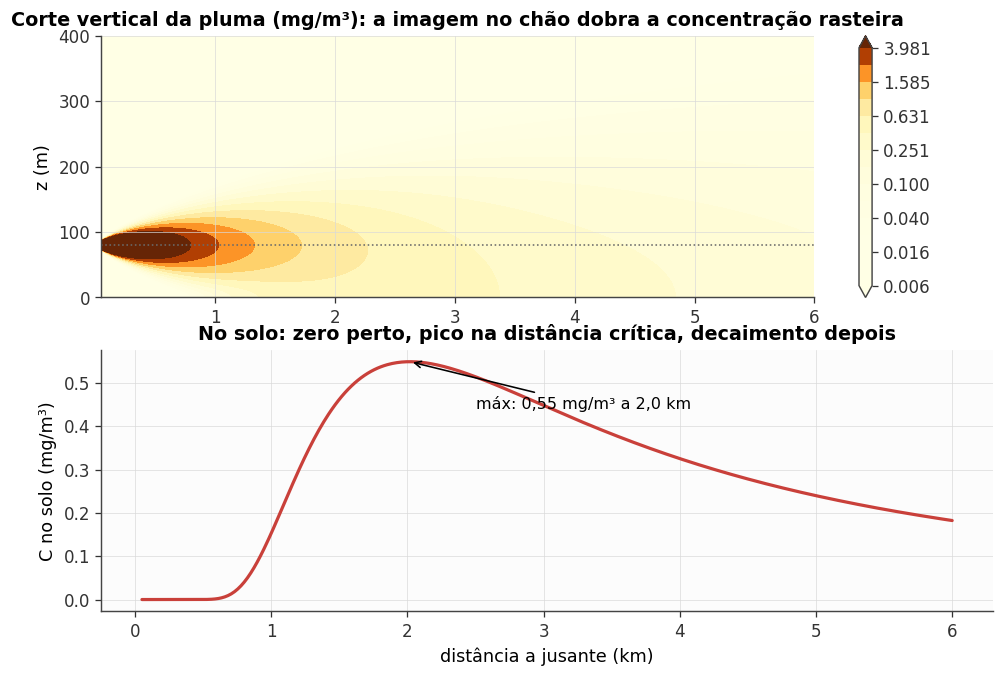

pico no solo a 2.0 km, onde sigma_z ~ H/sqrt(2) = 57 m (T3);
chamines altas nao eliminam a dose — empurram o maximo para longe e o diluem.


In [2]:
Q, U, H = 100.0, 5.0, 80.0                      # g/s, m/s, m
a_y, b_y, a_z, b_z = 0.08, 0.9, 0.06, 0.9       # classe ~C/D

def sig(x):
    return a_y*x**b_y, a_z*x**b_z

def C_conc(x, y, z):
    sy, sz = sig(x)
    return (Q/(2*np.pi*U*sy*sz)*np.exp(-y**2/(2*sy**2))*
            (np.exp(-(z-H)**2/(2*sz**2)) + np.exp(-(z+H)**2/(2*sz**2))))

x = np.linspace(50, 6000, 500)
z = np.linspace(0, 400, 240)
Xg, Zg = np.meshgrid(x, z)
campo = C_conc(Xg, 0.0, Zg)*1e3                 # mg/m³

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6.5))
cf = ax1.contourf(x/1e3, z, campo, levels=np.logspace(-2.2, 0.6, 15), cmap='YlOrBr',
                  extend='both')
ax1.axhline(H, color=CORES['cinza'], ls=':', lw=1)
ax1.set(ylabel='z (m)', title='Corte vertical da pluma (mg/m³): a imagem no chão dobra a concentração rasteira')
fig.colorbar(cf, ax=ax1)
C_solo = C_conc(x, 0.0, 0.0)*1e3
ax2.plot(x/1e3, C_solo, color=CORES['vermelho'], lw=2)
i_max = np.argmax(C_solo)
ax2.annotate(f'máx: {C_solo[i_max]:.2f} mg/m³ a {x[i_max]/1e3:.1f} km'.replace('.', ','),
             xy=(x[i_max]/1e3, C_solo[i_max]), xytext=(2.5, 0.8*C_solo[i_max]),
             fontsize=10, arrowprops=dict(arrowstyle='->'))
ax2.set(xlabel='distância a jusante (km)', ylabel='C no solo (mg/m³)',
        title='No solo: zero perto, pico na distância crítica, decaimento depois')
plt.show()
print(f'pico no solo a {x[i_max]/1e3:.1f} km, onde sigma_z ~ H/sqrt(2) = {H/np.sqrt(2):.0f} m (T3);')
print('chamines altas nao eliminam a dose — empurram o maximo para longe e o diluem.')

## Caso 2 — A estabilidade esculpe a pluma

Mesma fonte, três tardes diferentes (Cap. 5!): instável (*looping*), neutra (*coning*), estável (*fanning*). Simulamos com $\sigma$s de classes de Pasquill diferentes e um traçado de linha central serpenteante no caso instável.

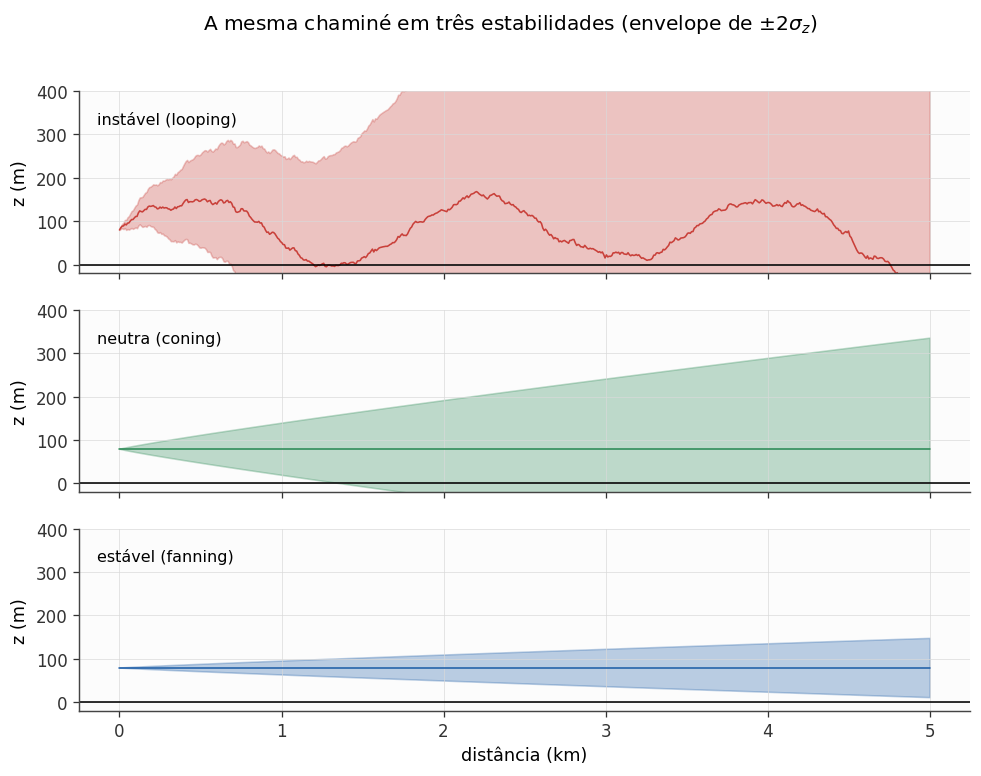

looping: termicas jogam a pluma no chao em golfadas (picos altos e breves);
fanning: a pluma estavel viaja fina a noite inteira — e desce TODA junta
na fumigacao da manha, quando a camada de mistura a alcanca (Cap. 18).


In [3]:
rng = np.random.default_rng(19)
x = np.linspace(0, 5000, 600)
classes = [('instável (looping)', 0.20, CORES['vermelho']),
           ('neutra (coning)', 0.06, CORES['verde']),
           ('estável (fanning)', 0.016, CORES['azul'])]

fig, axs = plt.subplots(3, 1, figsize=(10, 7), sharex=True, sharey=True)
for ax, (nome, az, cor) in zip(axs, classes):
    sz = az*x**0.9
    # linha central: serpenteia se instável (térmicas grandes)
    if 'instável' in nome:
        meander = np.cumsum(rng.standard_normal(x.size))*3.0
        meander = 80*np.sin(2*np.pi*x/1800) + meander - meander[0]
    else:
        meander = np.zeros_like(x)
    centro = 80.0 + meander
    ax.fill_between(x/1e3, centro - 2*sz, centro + 2*sz, color=cor, alpha=0.3)
    ax.plot(x/1e3, centro, color=cor, lw=1)
    ax.axhline(0, color='k', lw=1)
    ax.set_ylabel('z (m)')
    ax.text(0.02, 0.82, nome, transform=ax.transAxes, fontsize=10)
axs[0].set_ylim(-20, 400)
axs[-1].set_xlabel('distância (km)')
fig.suptitle('A mesma chaminé em três estabilidades (envelope de $\\pm2\\sigma_z$)')
plt.show()
print('looping: termicas jogam a pluma no chao em golfadas (picos altos e breves);')
print('fanning: a pluma estavel viaja fina a noite inteira — e desce TODA junta')
print('na fumigacao da manha, quando a camada de mistura a alcanca (Cap. 18).')

## Caso 3 — O modelo de caixa da cidade

Cidade de largura $W$, emissão $Q_A$ (por área), ventilada pelo vento $U$ através da altura $z_i$:
$$z_i\frac{dC}{dt} = Q_A - \frac{U\,z_i}{W}\,C.$$
O produto $U\,z_i$ é o **fator de ventilação** — quando a inversão abaixa o teto e o vento morre, vem o episódio.

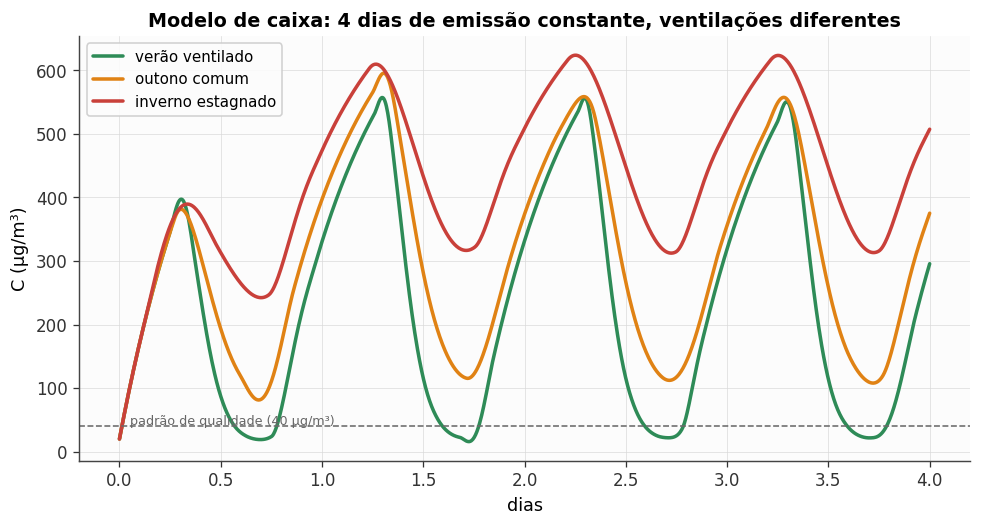

mesma emissao: o inverno estagnado (zi baixo + calmaria) acumula ate 3-4x mais —
os episodios classicos de SP/CETESB em junho-agosto sao meteorologia, nao pico de emissao.


In [4]:
W, QA = 40e3, 2e-6                              # m, g/m²/s

def zi_dia(t_h, zi_max):
    h = t_h % 24
    if 7 <= h <= 19:
        return 100 + (zi_max - 100)*np.sin(np.pi*(h - 7)/12)
    return 100.0

def U_dia(t_h, U_max):
    h = t_h % 24
    return 1.0 + (U_max - 1.0)*max(np.sin(np.pi*(h - 7)/12), 0)

def caixa(t, C, zi_max, U_max):
    t_h = t/3600
    zi, U = zi_dia(t_h, zi_max), U_dia(t_h, U_max)
    return [(QA - U*zi/W*C[0])/zi]

t_eval = np.linspace(0, 96*3600, 1200)
fig, ax = plt.subplots(figsize=(10, 4.8))
for zi_max, U_max, cor, nome in [(1800, 6, CORES['verde'], 'verão ventilado'),
                                  (800, 3, CORES['laranja'], 'outono comum'),
                                  (400, 1.5, CORES['vermelho'], 'inverno estagnado')]:
    s = solve_ivp(caixa, [0, 96*3600], [20e-6], args=(zi_max, U_max),
                  t_eval=t_eval, rtol=1e-8)
    ax.plot(t_eval/3600/24, s.y[0]*1e6, color=cor, label=nome)
ax.axhline(40, color=CORES['cinza'], ls='--', lw=1)
ax.text(0.05, 42, 'padrão de qualidade (40 µg/m³)', fontsize=8, color='#666666')
ax.set(xlabel='dias', ylabel='C (µg/m³)',
       title='Modelo de caixa: 4 dias de emissão constante, ventilações diferentes')
ax.legend()
plt.show()
print('mesma emissao: o inverno estagnado (zi baixo + calmaria) acumula ate 3-4x mais —')
print('os episodios classicos de SP/CETESB em junho-agosto sao meteorologia, nao pico de emissao.')

## Caso 4 — O passeio aleatório vira difusão

Cada bocado de fumaça dá passos aleatórios com a turbulência; o conjunto espalha com $\sigma^2 = 2Kt$ (T5). A ligação microscópico → macroscópico de Einstein (1905), com a turbulência no papel das moléculas.

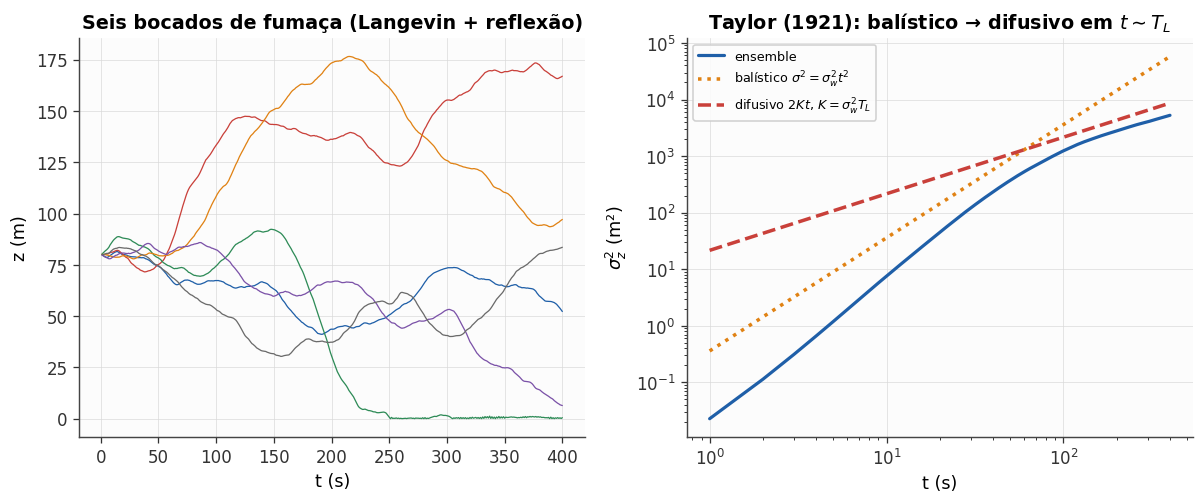

K efetivo = 6.6 m²/s vs teoria sigma_w²T_L = 10.8 m²/s;
os modelos de dispersao regulatorios (AERMOD etc.) sao exatamente isto em grande.


In [5]:
rng = np.random.default_rng(4)
n_part, n_step = 3000, 400
dt, sigma_w, T_L = 1.0, 0.6, 30.0               # s, m/s, escala lagrangiana
a = np.exp(-dt/T_L)                             # memória (Langevin)

w = np.zeros(n_part)
zpos = np.full(n_part, 80.0)
tra = np.zeros((n_step, 6))
var = np.zeros(n_step)
for k in range(n_step):
    w = a*w + np.sqrt(1 - a**2)*sigma_w*rng.standard_normal(n_part)
    zpos = np.abs(zpos + w*dt)                  # reflexão no chão
    var[k] = np.var(zpos)
    tra[k] = zpos[:6]

t = np.arange(1, n_step + 1)*dt
K_teo = sigma_w**2*T_L
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.5))
ax1.plot(t, tra, lw=0.8)
ax1.set(xlabel='t (s)', ylabel='z (m)', title='Seis bocados de fumaça (Langevin + reflexão)')
ax2.loglog(t, var, color=CORES['azul'], lw=2, label='ensemble')
ax2.loglog(t, sigma_w**2*t**2, ':', color=CORES['laranja'], label='balístico $\\sigma^2 = \\sigma_w^2t^2$')
ax2.loglog(t, 2*K_teo*t, '--', color=CORES['vermelho'], label=f'difusivo $2Kt$, $K = \\sigma_w^2 T_L$')
ax2.set(xlabel='t (s)', ylabel='$\\sigma_z^2$ (m²)', title='Taylor (1921): balístico → difusivo em $t \\sim T_L$')
ax2.legend(fontsize=8)
plt.show()
print(f'K efetivo = {var[-1]/(2*t[-1]):.1f} m²/s vs teoria sigma_w²T_L = {K_teo:.1f} m²/s;')
print('os modelos de dispersao regulatorios (AERMOD etc.) sao exatamente isto em grande.')

---
## Exercícios numéricos complementares

Enunciados completos (e teóricos T1–T5) nas notas de aula; **soluções em `cap19_solucoes.ipynb`**.

**N1** — Varra a altura da chaminé (20–200 m) no Caso 1 e trace o pico de concentração no solo e sua distância; verifique $C_{max} \propto 1/H^2$.

**N2** — Simule a fumigação da manhã: pluma *fanning* noturna a 200 m capturada por uma camada de mistura que cresce (Cap. 18); trace a concentração no solo hora a hora.

**N3** — No modelo de caixa, imponha o ciclo real de emissão veicular (dois picos: 8h e 18h) e compare o horário dos máximos de C com o das emissões; por que o pico noturno de poluição vem DEPOIS do pico do tráfego?

**N4** — No passeio aleatório, varra $T_L$ (5–120 s) e mostre que o $K$ efetivo escala como $\sigma_w^2 T_L$; o que acontece com a pluma perto da fonte ($t < T_L$)?

In [6]:
# N1 — sua solução aqui


In [7]:
# N2 — sua solução aqui


In [8]:
# N3 — sua solução aqui


In [9]:
# N4 — sua solução aqui


---
*Material derivado de R. Stull, Practical Meteorology (CC BY-NC-SA 4.0); este notebook herda a mesma licença.*